# Sistema de Deteccion de Spam en URLs

En este notebook vamos a construir un modelo capaz de detectar si una URL es spam o no. Para ello usaremos un SVM (Support Vector Machine), que es un clasificador bastante robusto para este tipo de problemas con texto.

El flujo que seguiremos es el siguiente:
1. Cargamos el dataset
2. Preprocesamos las URLs
3. Entrenamos un SVM basico
4. Optimizamos el modelo con busqueda de hiperparametros
5. Guardamos el modelo final

## 1. Imports y configuracion inicial

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os
import warnings
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Descargamos los recursos de NLTK que necesitamos
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Fijamos una semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 2. Carga del dataset

Cargamos el archivo `url_spam.csv` directamente desde la URL proporcionada. Si tienes el archivo en local, puedes cambiar la ruta.

In [28]:
# Cargamos el dataset
df = pd.read_csv('../data/raw/url_spam.csv')

print(f'Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas')
print()
print('Primeras filas:')
df.head()

Dataset cargado: 2999 filas y 2 columnas

Primeras filas:


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [29]:
# Revisamos la informacion general del dataset
print('Informacion general:')
df.info()
print()

# Miramos cuantas URLs hay de cada clase
print('Distribucion de clases:')
print(df.iloc[:, -1].value_counts())

Informacion general:
<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2999 non-null   str  
 1   is_spam  2999 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 26.5 KB

Distribucion de clases:
is_spam
False    2303
True      696
Name: count, dtype: int64


In [30]:
# Asignamos nombres a las columnas si no los tienen, o identificamos cuales son
# Por convenio asumimos que la primera columna es la URL y la segunda es la etiqueta
print('Nombres de columnas:', df.columns.tolist())
print()

# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Nombres de columnas: ['url', 'is_spam']

Valores nulos por columna:
url        0
is_spam    0
dtype: int64


No presenta valores nulos, por lo tanto no tenemos que hacer limpieza de datos 

In [31]:
# Identificamos la columna de URL y la de etiqueta y Renombramos para trabajar mejor
url_col = df.columns[0]
label_col = df.columns[1]

df = df.rename(columns={url_col: 'url', label_col: 'label'})

# Eliminamos filas con nulos si los hay
df = df.dropna(subset=['url', 'label'])

print(f'Dataset limpio: {df.shape[0]} filas')
print()
print('Valores unicos en label:', df['label'].unique())

Dataset limpio: 2999 filas

Valores unicos en label: [ True False]


### Visualizacion de la distribucion de clases

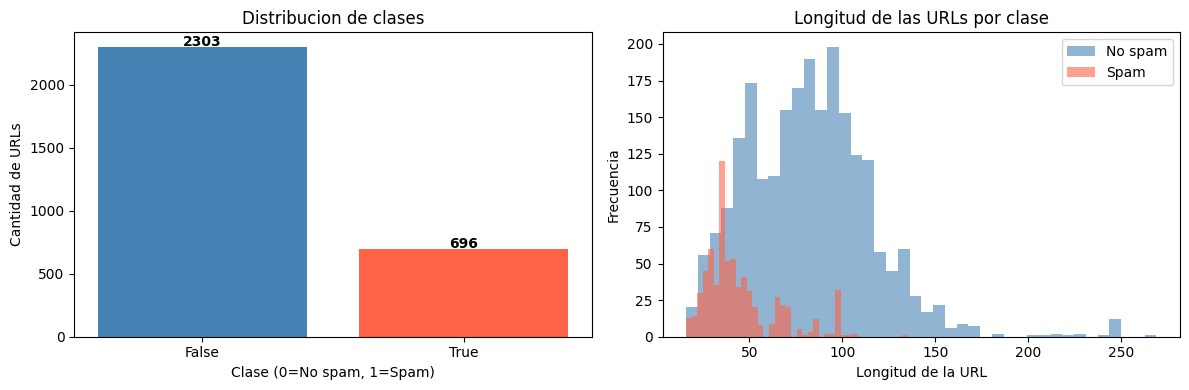

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo de clases
conteo = df['label'].value_counts()
axes[0].bar(conteo.index.astype(str), conteo.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribucion de clases')
axes[0].set_xlabel('Clase (0=No spam, 1=Spam)')
axes[0].set_ylabel('Cantidad de URLs')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Longitud de las URLs
df['url_length'] = df['url'].apply(len)
axes[1].hist(df[df['label'] == 0]['url_length'], bins=40, alpha=0.6, label='No spam', color='steelblue')
axes[1].hist(df[df['label'] == 1]['url_length'], bins=40, alpha=0.6, label='Spam', color='tomato')
axes[1].set_title('Longitud de las URLs por clase')
axes[1].set_xlabel('Longitud de la URL')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Preprocesamiento de las URLs

Las URLs no son texto normal, asi que hay que tratarlas de una manera especial. Lo que vamos a hacer es:

1. Segmentar la URL por signos de puntuacion y caracteres especiales (`.`, `/`, `-`, `_`, `?`, `=`, `&`, etc.)
2. Convertir todo a minusculas
3. Eliminar tokens que sean solo numeros o que sean muy cortos
4. Eliminar stopwords en ingles
5. Aplicar lematizacion para reducir las palabras a su forma base

In [33]:
# Preparamos el lematizador y las stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocesar_url(url):

    url = url.lower()

    tokens = re.split(r'[^a-z]+', url)
    
    tokens_limpios = []
    for token in tokens:
        if len(token) > 2 and token not in stop_words:
            
            token_lema = lemmatizer.lemmatize(token)
            tokens_limpios.append(token_lema)
    
    return ' '.join(tokens_limpios)


# Probamos la funcion con un ejemplo
url_ejemplo = 'http://www.example.com/free-money/click-here?promo=true&id=12345'
print('URL original:', url_ejemplo)
print('URL procesada:', preprocesar_url(url_ejemplo))

URL original: http://www.example.com/free-money/click-here?promo=true&id=12345
URL procesada: http www example com free money click promo true


In [34]:
# Aplicamos el preprocesamiento a todo el dataset
print('Procesando URLs...')
df['url_procesada'] = df['url'].apply(preprocesar_url)
print('Listo!')
print()

# Vemos el resultado
df[['url', 'url_procesada', 'label']].head(10)

Procesando URLs...
Listo!



,url,url_procesada,label
0,https://briefingday.us8.list-manage.com/unsubs...,http briefingday list manage com unsubscribe,True
1,https://www.hvper.com/,http www hvper com,True
2,https://briefingday.com/m/v4n3i4f3,http briefingday com,True
3,https://briefingday.com/n/20200618/m#commentform,http briefingday com commentform,False
4,https://briefingday.com/fan,http briefingday com fan,True
5,https://www.brookings.edu/interactives/reopeni...,http www brookings edu interactives reopening ...,False
6,https://www.reuters.com/investigates/special-r...,http www reuters com investigates special repo...,False
7,https://www.theatlantic.com/magazine/archive/2...,http www theatlantic com magazine archive supe...,False
8,https://www.vox.com/2020/6/17/21294680/john-bo...,http www vox com john bolton book excerpt trum...,False
9,https://www.theguardian.com/travel/2020/jun/18...,http www theguardian com travel jun end touris...,False


In [35]:
# Eliminamos filas donde el procesamiento haya dejado la URL vacia
df = df[df['url_procesada'].str.strip() != '']
print(f'Filas despues de limpiar URLs vacias: {df.shape[0]}')

Filas despues de limpiar URLs vacias: 2999


## 4. Division en train y test

Dividimos el dataset en 80% para entrenamiento y 20% para test. Usamos `stratify` para que la proporcion de spam/no-spam sea la misma en ambas partes.

In [36]:
X = df['url_procesada']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=SEED, stratify=y )

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]}')
print(f'Tamaño del conjunto de test: {X_test.shape[0]}')
print()
print('Distribucion en train:')
print(y_train.value_counts())
print()
print('Distribucion en test:')
print(y_test.value_counts())

Tamaño del conjunto de entrenamiento: 2399
Tamaño del conjunto de test: 600

Distribucion en train:
label
False    1842
True      557
Name: count, dtype: int64

Distribucion en test:
label
False    461
True     139
Name: count, dtype: int64


## 5. Vectorizacion con TF-IDF

Antes de entrenar el modelo necesitamos convertir el texto a numeros. Usamos TF-IDF (Term Frequency - Inverse Document Frequency), que asigna un peso a cada palabra segun cuanto aparece en un documento comparado con el resto.

Combinamos el vectorizador y el clasificador en un `Pipeline` para que todo el proceso sea mas limpio y facil de usar.

## 6. Entrenamiento del SVM con parametros por defecto

Empezamos con un SVM con los parametros que trae scikit-learn por defecto, para tener una referencia de rendimiento antes de optimizar.

In [37]:
# Creamos el pipeline con TF-IDF + SVM
pipeline_base = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convierte el texto a matriz numerica
    ('svm', SVC(random_state=SEED))  # Clasificador SVM con parametros por defecto
])

# Entrenamos el modelo
print('Entrenando SVM base...')
pipeline_base.fit(X_train, y_train)
print('Entrenamiento terminado!')

Entrenando SVM base...
Entrenamiento terminado!


In [38]:
# Hacemos predicciones sobre el conjunto de test
y_pred_base = pipeline_base.predict(X_test)

# Mostramos los resultados
print('=== Resultados del SVM base ===')
print()
print(f'Accuracy: {accuracy_score(y_test, y_pred_base):.4f}')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred_base, target_names=['No spam', 'Spam']))

=== Resultados del SVM base ===

Accuracy: 0.9267

Reporte completo:
              precision    recall  f1-score   support

     No spam       0.96      0.94      0.95       461
        Spam       0.82      0.87      0.85       139

    accuracy                           0.93       600
   macro avg       0.89      0.91      0.90       600
weighted avg       0.93      0.93      0.93       600



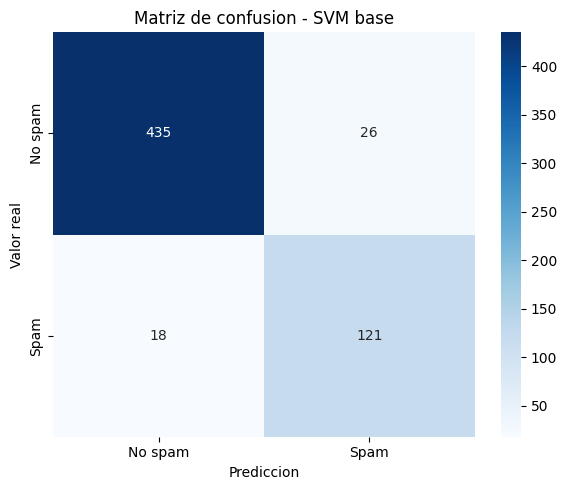

In [39]:
# Visualizamos la matriz de confusion del modelo base
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No spam', 'Spam'],
    yticklabels=['No spam', 'Spam']
)
plt.title('Matriz de confusion - SVM base')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

## 7. Optimizacion de hiperparametros con RandomizedSearchCV

Ahora vamos a buscar mejores hiperparametros para el SVM. Usamos `RandomizedSearchCV` en lugar de `GridSearchCV` porque es mas rapido: en vez de probar todas las combinaciones posibles, prueba una muestra aleatoria de ellas.

Los hiperparametros que exploraremos son:
- `C`: controla cuanto penaliza los errores de clasificacion (mayor C = menos margen pero menos errores en train)
- `kernel`: la funcion que define como se separan las clases
- `gamma`: influye en cuanto 'radio de accion' tiene cada punto (solo para kernels no lineales)
- `tfidf__max_features`: cuantas palabras distintas usa el vectorizador
- `tfidf__ngram_range`: si usamos palabras individuales, pares de palabras, etc.

In [40]:
param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Unigramas o unigramas+bigramas
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  # Solo aplica para kernel rbf
}

# Creamos un nuevo pipeline para la busqueda
pipeline_opt = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC(random_state=SEED))
])

random_search = RandomizedSearchCV(
    pipeline_opt,
    param_distributions=param_grid,
    n_iter=15,          # Probamos 15 combinaciones aleatorias
    cv=3,               # Validacion cruzada de 3 pliegues
    scoring='f1',       # Optimizamos por F1 (buen balance entre precision y recall)
    random_state=SEED,
    n_jobs=-1,          # Usamos todos los nucleos disponibles
    verbose=1
)

print('Iniciando busqueda de hiperparametros...')
print('Esto puede tardar unos minutos.')
random_search.fit(X_train, y_train)
print()
print('Busqueda terminada!')

Iniciando busqueda de hiperparametros...
Esto puede tardar unos minutos.
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Busqueda terminada!


In [41]:
print('Mejores parametros encontrados:')
for param, valor in random_search.best_params_.items():
    print(f'  {param}: {valor}')

print()
print(f'Mejor F1 en validacion cruzada: {random_search.best_score_:.4f}')

Mejores parametros encontrados:
  tfidf__ngram_range: (1, 2)
  tfidf__max_features: 5000
  svm__kernel: rbf
  svm__gamma: scale
  svm__C: 100

Mejor F1 en validacion cruzada: 0.8750


In [42]:
mejor_modelo = random_search.best_estimator_
y_pred_opt = mejor_modelo.predict(X_test)

print('=== Resultados del SVM optimizado ===')
print()
print(f'Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred_opt, target_names=['No spam', 'Spam']))

=== Resultados del SVM optimizado ===

Accuracy: 0.9550

Reporte completo:
              precision    recall  f1-score   support

     No spam       0.97      0.97      0.97       461
        Spam       0.90      0.91      0.90       139

    accuracy                           0.95       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.96      0.95      0.96       600



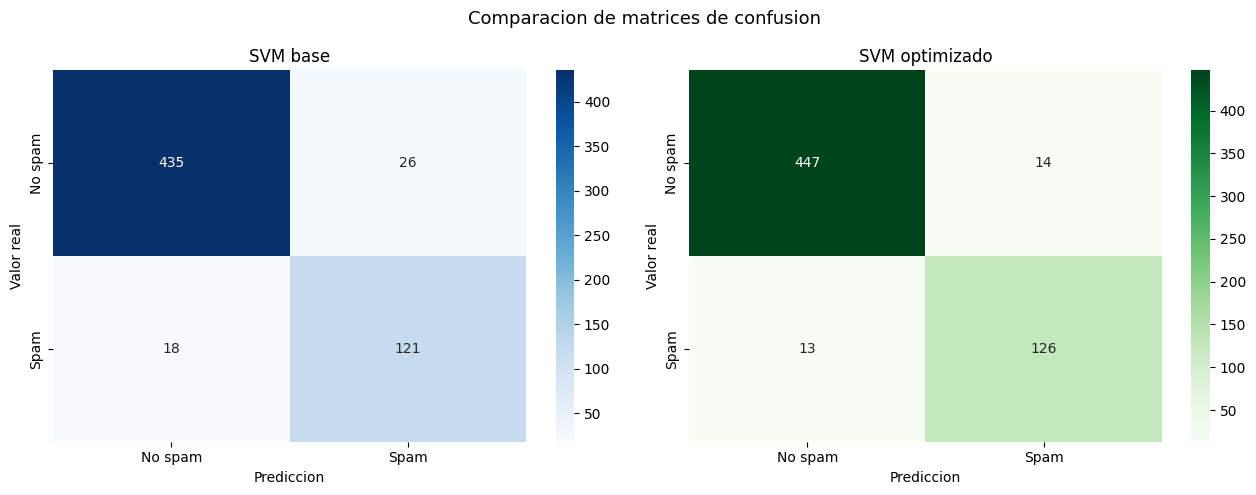

In [43]:
# Visualizamos la matriz de confusion del modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Modelo base
sns.heatmap(
    cm_base, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No spam', 'Spam'],
    yticklabels=['No spam', 'Spam'],
    ax=axes[0]
)
axes[0].set_title('SVM base')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Valor real')

# Modelo optimizado
sns.heatmap(
    cm_opt, annot=True, fmt='d', cmap='Greens',
    xticklabels=['No spam', 'Spam'],
    yticklabels=['No spam', 'Spam'],
    ax=axes[1]
)
axes[1].set_title('SVM optimizado')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Valor real')

plt.suptitle('Comparacion de matrices de confusion', fontsize=13)
plt.tight_layout()
plt.show()

### Comparacion de metricas

                Accuracy  Precision  Recall      F1
Modelo                                             
SVM base          0.9267     0.8231  0.8705  0.8462
SVM optimizado    0.9550     0.9000  0.9065  0.9032



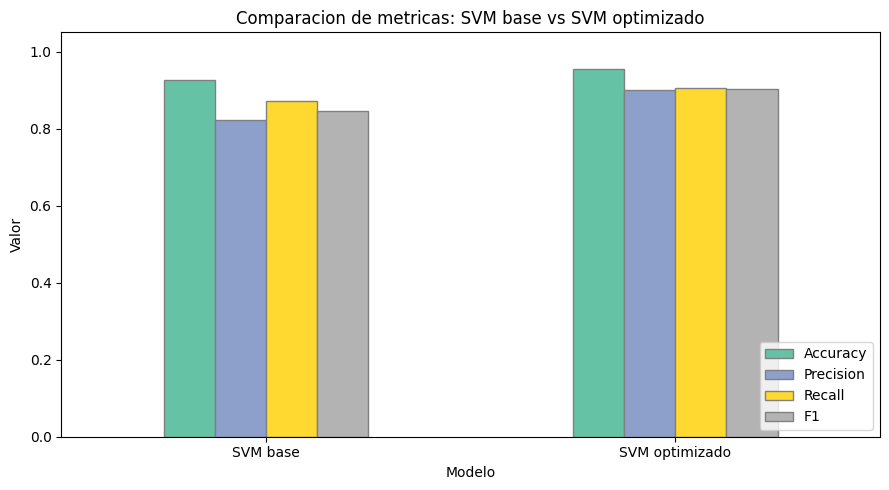

In [44]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Calculamos metricas para ambos modelos
metricas = {
    'Modelo': ['SVM base', 'SVM optimizado'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_opt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_opt)
    ],
    'Recall': [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_opt)
    ],
    'F1': [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_opt)
    ]
}

df_metricas = pd.DataFrame(metricas)
df_metricas = df_metricas.set_index('Modelo')
print(df_metricas.round(4))
print()

# Visualizacion de la comparacion
df_metricas.plot(kind='bar', figsize=(9, 5), colormap='Set2', edgecolor='gray')
plt.title('Comparacion de metricas: SVM base vs SVM optimizado')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Guardado del modelo

Guardamos el mejor modelo encontrado usando `joblib`, que es la forma habitual de serializar modelos de scikit-learn. Tambien guardamos la funcion de preprocesamiento de URLs en un archivo aparte para poder reutilizarla luego.

In [45]:
# Creamos la carpeta donde guardaremos el modelo si no existe
carpeta_modelos = 'models'
os.makedirs(carpeta_modelos, exist_ok=True)

# Guardamos el pipeline completo (incluye el vectorizador TF-IDF y el SVM)
ruta_modelo = os.path.join(carpeta_modelos, 'spam_detector_svm.joblib')
joblib.dump(mejor_modelo, ruta_modelo)

print(f'Modelo guardado en: {ruta_modelo}')

Modelo guardado en: models/spam_detector_svm.joblib


In [46]:
# Verificamos que el modelo se puede cargar y funciona correctamente
modelo_cargado = joblib.load(ruta_modelo)

# Probamos con algunas URLs de ejemplo
urls_prueba = [
    'https://www.google.com/search?q=python',
    'http://free-money-click-here-now.xyz/win/promo?id=999',
    'https://github.com/scikit-learn/scikit-learn',
    'http://buy-cheap-pills-online.ru/order?discount=90'
]

# Preprocesamos las URLs de prueba
urls_procesadas = [preprocesar_url(url) for url in urls_prueba]

# Hacemos predicciones
predicciones = modelo_cargado.predict(urls_procesadas)

print('Predicciones del modelo cargado:')
print()
for url, pred in zip(urls_prueba, predicciones):
    etiqueta = 'SPAM' if pred == 1 else 'No spam'
    print(f'  [{etiqueta}] {url}')

Predicciones del modelo cargado:

  [No spam] https://www.google.com/search?q=python
  [No spam] http://free-money-click-here-now.xyz/win/promo?id=999
  [No spam] https://github.com/scikit-learn/scikit-learn
  [No spam] http://buy-cheap-pills-online.ru/order?discount=90


## 9. Resumen

En este notebook hemos construido un sistema de deteccion de spam en URLs siguiendo estos pasos:

**Preprocesamiento**: Segmentamos las URLs por signos de puntuacion, eliminamos stopwords y aplicamos lematizacion para extraer el vocabulario relevante de cada URL.

**Vectorizacion**: Usamos TF-IDF para convertir el texto preprocesado en una representacion numerica que el modelo puede entender.

**Modelo base**: Entrenamos un SVM con los parametros por defecto para tener una linea de referencia.

**Optimizacion**: Realizamos una busqueda aleatoria de hiperparametros con `RandomizedSearchCV`, lo que nos permitio mejorar el rendimiento del modelo.

**Guardado**: Exportamos el pipeline completo con `joblib`, de forma que el preprocesamiento y el modelo viajan juntos y se pueden reutilizar facilmente.

El pipeline guarda juntos el vectorizador y el clasificador, por lo que para usar el modelo en produccion solo necesitamos:
1. Cargar el archivo con `joblib.load`
2. Preprocesar las URLs nuevas con `preprocesar_url`
3. Llamar a `.predict()` directamente